In [1]:
import pandas as pd

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing import sequence

In [2]:
import tensorflow as tf
from tensorflow import keras

In [3]:
data = pd.read_csv("fake reviews dataset.csv")

In [4]:
data.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [5]:
import re
import unicodedata
from bs4 import BeautifulSoup

# FOR STEMMING AND REMOVING STOP WORDS
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer   
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize

In [6]:
nltk.download('stopwords')
#### CACHING THE STOP WORDS HELPS IN FASTENING THE REMOVAL OF THE STOP WORDS
cachedStopWords = stopwords.words("english")
nltk.download('wordnet')
nltk.download('words')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')

lemmatizer=WordNetLemmatizer()
corpus_words = set(nltk.corpus.words.words())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\farza\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\farza\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\farza\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\farza\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\farza\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [7]:
CONTRACTION_MAP = {"ain't": "is not","aren't": "are not","can't": "cannot","can't've": "cannot have","'cause": "because","could've": "could have","couldn't": "could not","couldn't've": "could not have","didn't": "did not","doesn't": "does not","don't": "do not","hadn't": "had not","hadn't've": "had not have","hasn't": "has not","haven't": "have not","he'd": "he would","he'd've": "he would have","he'll": "he will","he'll've": "he he will have","he's": "he is","how'd": "how did","how'd'y": "how do you","how'll": "how will","how's": "how is","I'd": "I would","I'd've": "I would have","I'll": "I will","I'll've": "I will have","I'm": "I am","I've": "I have","i'd": "i would","i'd've": "i would have","i'll": "i will","i'll've": "i will have","i'm": "i am","i've": "i have","isn't": "is not","it'd": "it would","it'd've": "it would have","it'll": "it will","it'll've": "it will have","it's": "it is","let's": "let us","ma'am": "madam","mayn't": "may not","might've": "might have","mightn't": "might not","mightn't've": "might not have","must've": "must have","mustn't": "must not","mustn't've": "must not have","needn't": "need not","needn't've": "need not have","o'clock": "of the clock","oughtn't": "ought not","oughtn't've": "ought not have","shan't": "shall not","sha'n't": "shall not","shan't've": "shall not have","she'd": "she would","she'd've": "she would have","she'll": "she will","she'll've": "she will have","she's": "she is","should've": "should have","shouldn't": "should not","shouldn't've": "should not have","so've": "so have","so's": "so as","that'd": "that would","that'd've": "that would have","that's": "that is","there'd": "there would","there'd've": "there would have","there's": "there is","they'd": "they would","they'd've": "they would have","they'll": "they will","they'll've": "they will have","they're": "they are","they've": "they have","to've": "to have","wasn't": "was not","we'd": "we would","we'd've": "we would have","we'll": "we will","we'll've": "we will have","we're": "we are","we've": "we have","weren't": "were not","what'll": "what will","what'll've": "what will have","what're": "what are","what's": "what is","what've": "what have","when's": "when is","when've": "when have","where'd": "where did","where's": "where is","where've": "where have","who'll": "who will","who'll've": "who will have","who's": "who is","who've": "who have","why's": "why is","why've": "why have","will've": "will have","won't": "will not","won't've": "will not have","would've": "would have","wouldn't": "would not","wouldn't've": "would not have","y'all": "you all","y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have","you'd": "you would","you'd've": "you would have","you'll": "you will","you'll've": "you will have","you're": "you are","you've": "you have"}

In [8]:
def cleanData(data, text_column):
    # Helper functions
    def removeAscentedCharacters(text):
        return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')

    def expandContractions(text, contraction_mapping):
        contractions_pattern = re.compile('({})'.format('|'.join(contraction_mapping.keys())), flags=re.IGNORECASE|re.DOTALL)
        def expand_match(contraction):
            match = contraction.group(0)
            expanded_contraction = contraction_mapping.get(match.lower())
            return expanded_contraction
        expanded_text = contractions_pattern.sub(expand_match, text)
        return re.sub("'", "", expanded_text)

    def removeIC(text):
        return text.strip('"')

    def remove_tags(text):
        return BeautifulSoup(text, "html.parser").get_text()

    def removeLinks(text):
        return re.sub(r'http\S+', '', text)

    def removeSpecialCharacters(text):
        return re.sub(r'[^a-zA-Z0-9\s]', '', text)

    def removeSpaces(text):
        return " ".join(text.split())
    
    def convertToLowercase(text):
        return text.lower()
    
    def removeStopWords(text):
        stop_words = set(stopwords.words('english'))
        word_tokens = word_tokenize(text)
        filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
        return ' '.join(filtered_sentence)

    # Apply cleaning functions to the text column
    data[text_column] = data[text_column].apply(removeAscentedCharacters)
    data[text_column] = data[text_column].apply(expandContractions, contraction_mapping=CONTRACTION_MAP)
    data[text_column] = data[text_column].apply(removeIC)
    data[text_column] = data[text_column].apply(remove_tags)
    data[text_column] = data[text_column].apply(removeLinks)
    data[text_column] = data[text_column].apply(removeSpecialCharacters)
    data[text_column] = data[text_column].apply(removeSpaces)
    data[text_column] = data[text_column].apply(convertToLowercase)
    data[text_column] = data[text_column].apply(removeStopWords)

    return data

In [9]:
cleaned_data = cleanData(data, 'text_')

C:\Users\farza\AppData\Local\Temp\ipykernel_12584\1436793348.py:19: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()


In [10]:
cleaned_data.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,love well made sturdy comfortable love itvery ...
1,Home_and_Kitchen_5,5.0,CG,love great upgrade original mine couple years
2,Home_and_Kitchen_5,5.0,CG,pillow saved back love look feel pillow
3,Home_and_Kitchen_5,1.0,CG,missing information use great product price
4,Home_and_Kitchen_5,5.0,CG,nice set good quality set two months


In [11]:
cleaned_data.tail()

,category,rating,label,text_
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,read reviews saying bra ran small ordered two ...
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,sure exactly would little large small size thi...
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,wear hood wear hood wear jacket without hood 3...
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,liked nothing dress reason gave 4 stars ordere...
40431,Clothing_Shoes_and_Jewelry_5,5.0,OR,work wedding industry work long days feet outs...


## EDA

In [15]:
#Visualization libraries
import matplotlib.pyplot as plt 
from matplotlib import rcParams
import seaborn as sns
from textblob import TextBlob
from plotly import tools
import plotly.graph_objs as go
from plotly.offline import iplot
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 5]
import cufflinks as cf
cf.go_offline()
cf.set_config_file(offline=False, world_readable=True)

In [16]:
cleaned_data.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,love well made sturdy comfortable love itvery ...
1,Home_and_Kitchen_5,5.0,CG,love great upgrade original mine couple years
2,Home_and_Kitchen_5,5.0,CG,pillow saved back love look feel pillow
3,Home_and_Kitchen_5,1.0,CG,missing information use great product price
4,Home_and_Kitchen_5,5.0,CG,nice set good quality set two months


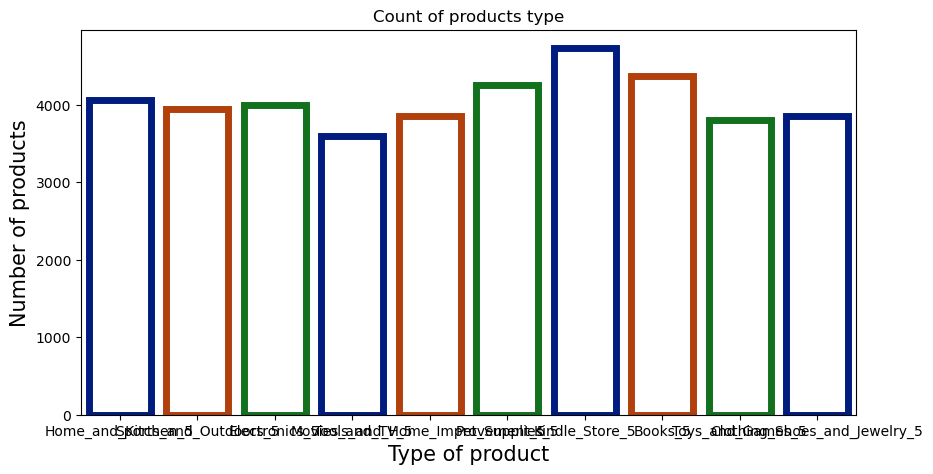

In [17]:
#Plotting the frequency plot
ax = sns.countplot(x="category", data=cleaned_data,
                   facecolor=(0, 0, 0, 0),
                   linewidth=5,
                   edgecolor=sns.color_palette("dark", 3))

#Setting labels and font size
ax.set(xlabel='Type of product', ylabel='Number of products',title='Count of products type')
ax.xaxis.get_label().set_fontsize(15)
ax.yaxis.get_label().set_fontsize(15)

C:\Users\farza\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning:

The figure layout has changed to tight



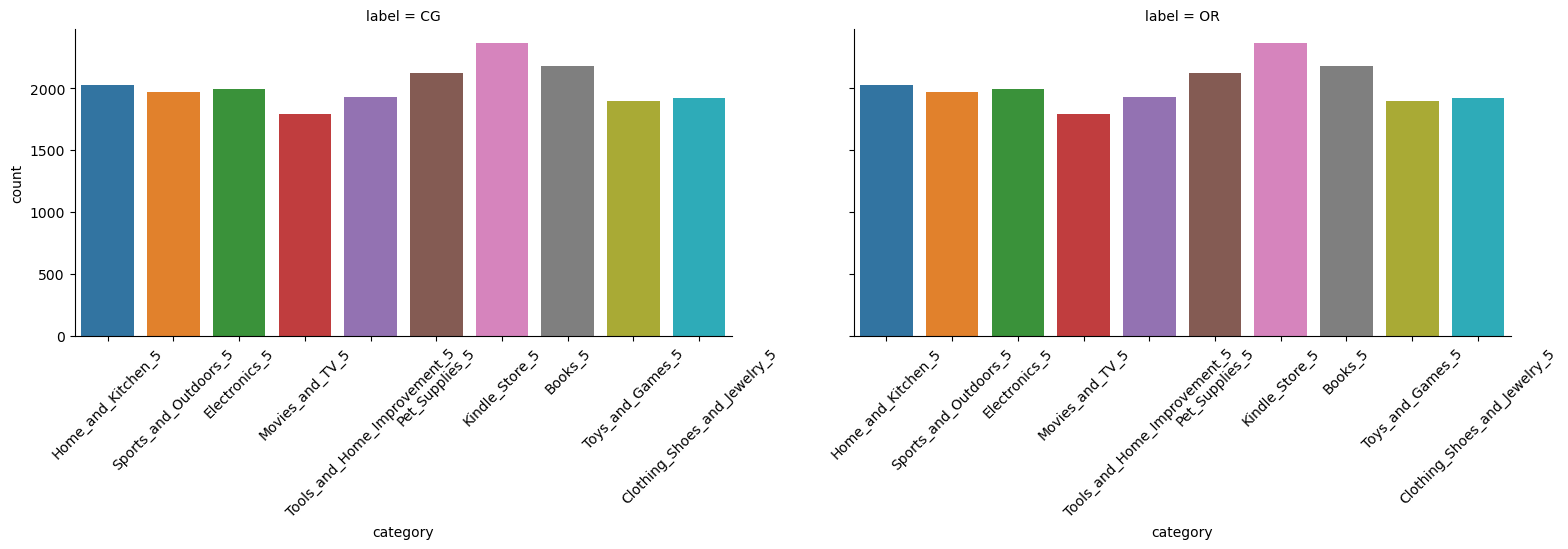

In [18]:
g = sns.catplot(x="category", col="label",
                data=cleaned_data, kind="count",
                height=4, aspect=2)

#Rotating the xlabels
g.set_xticklabels(rotation=45)

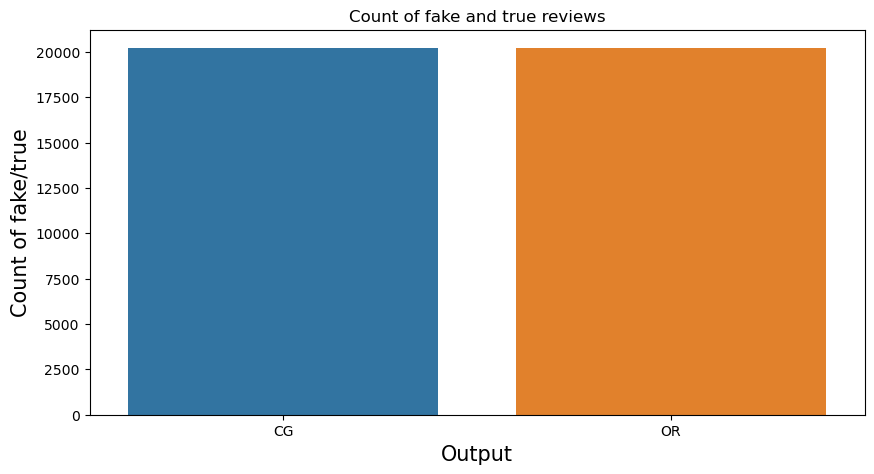

In [20]:
ax=sns.countplot(x="label", data=cleaned_data)

#Setting labels and font size
ax.set(xlabel='Output', ylabel='Count of fake/true',title='Count of fake and true reviews')
ax.xaxis.get_label().set_fontsize(15)
ax.yaxis.get_label().set_fontsize(15)

C:\Users\farza\AppData\Local\Temp\ipykernel_20560\843304915.py:8: MatplotlibDeprecationWarning:

The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.

C:\Users\farza\AppData\Local\Temp\ipykernel_20560\843304915.py:10: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\farza\AppData\Local\Temp\ipykernel_20560\843304915.py:13: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displo

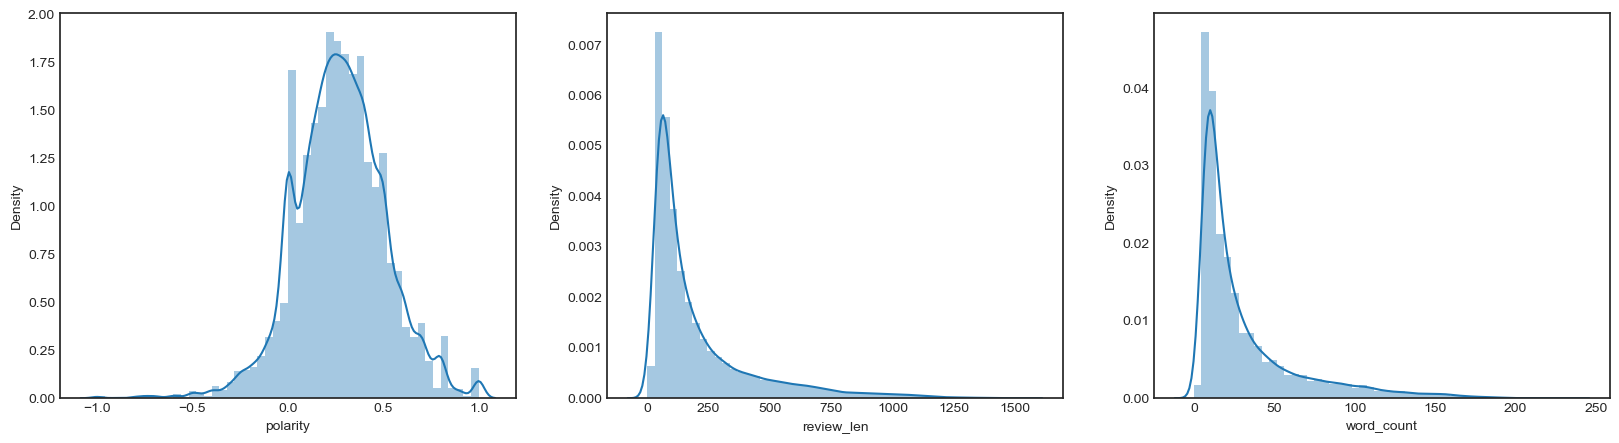

In [21]:
#Extracting the features from the news
cleaned_data['polarity'] = cleaned_data['text_'].map(lambda text: TextBlob(text).sentiment.polarity)
cleaned_data['review_len'] = cleaned_data['text_'].astype(str).apply(len)
cleaned_data['word_count'] = cleaned_data['text_'].apply(lambda x: len(str(x).split()))

#Plotting the distribution of the extracted feature
plt.figure(figsize = (20, 5))
plt.style.use('seaborn-white')
plt.subplot(131)
sns.distplot(cleaned_data['polarity'])
fig = plt.gcf()
plt.subplot(132)
sns.distplot(cleaned_data['review_len'])
fig = plt.gcf()
plt.subplot(133)
sns.distplot(cleaned_data['word_count'])
fig = plt.gcf()

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

In [25]:
def get_top_n_words(corpus, n=None):
    vec = CountVectorizer().fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

#Calling function and return only top 20 words
common_words = get_top_n_words(cleaned_data['text_'], 20)

#Printing the word and frequency
for word, freq in common_words:
    print(word, freq)

#Creating the dataframe of word and frequency
df1 = pd.DataFrame(common_words, columns = ['text_' , 'count'])

#Group by words and plot the sum
df1.groupby('text_').sum()['count'].sort_values(ascending=False).iplot(
    kind='bar', yTitle='Count', linecolor='black', title='Top 20 words in news')

great 16420
book 15002
good 14200
one 13395
would 11723
love 10805
well 10227
story 9627
like 9428
read 8868
little 8144
get 6467
recommend 6179
characters 6151
really 6119
use 5923
bought 5736
also 5721
movie 5548
nice 5036


In [26]:
#Function to get top bigram words
def get_top_n_bigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

#Calling function and return only top 20 words
common_words = get_top_n_bigram(cleaned_data['text_'], 20)

#Printing the word and frequency
for word, freq in common_words:
    print(word, freq)
    
#Creating the dataframe of word and frequency
df3 = pd.DataFrame(common_words, columns = ['text_' , 'count'])

#Group by words and plot the sum
df3.groupby('text_').sum()['count'].sort_values(ascending=False).iplot(
    kind='bar', yTitle='Count', linecolor='black', title='Top 20 bigrams in news')

would recommend 3009
highly recommend 1433
well written 1322
well made 1250
well developed 1185
characters well 1175
recommend anyone 1122
year old 1103
read book 1066
works great 1043
enjoyed book 963
really enjoyed 899
exchange honest 875
story well 837
would definitely 819
recommend book 801
long time 799
story line 786
good story 748
honest review 738


In [27]:
#Function to get top trigram words
def get_top_n_trigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

#Calling function and return only top 20 words
common_words = get_top_n_trigram(cleaned_data['text_'], 20)

#Printing word and their respective frequencies
for word, freq in common_words:
    print(word, freq)

#Creating a dataframe with words and count
df6 = pd.DataFrame(common_words, columns = ['text_' , 'count'])

#Grouping the words and plotting their frequencies
df6.groupby('text_').sum()['count'].sort_values(ascending=False).iplot(
    kind='bar', yTitle='Count', linecolor='black', title='Top 20 trigrams in news')

exchange honest review 534
reason gave stars 514
really enjoyed book 433
looking forward reading 384
good acting good 378
acting good acting 323
book exchange honest 309
look forward reading 268
characters developed story 263
problem comes small 253
good story good 244
problem kind hard 226
comes small screw 205
received free copy 196
bought son christmas 189
product great price 188
copy book exchange 185
free copy book 184
read books series 179
characters story line 169


In [28]:
from wordcloud import WordCloud,STOPWORDS

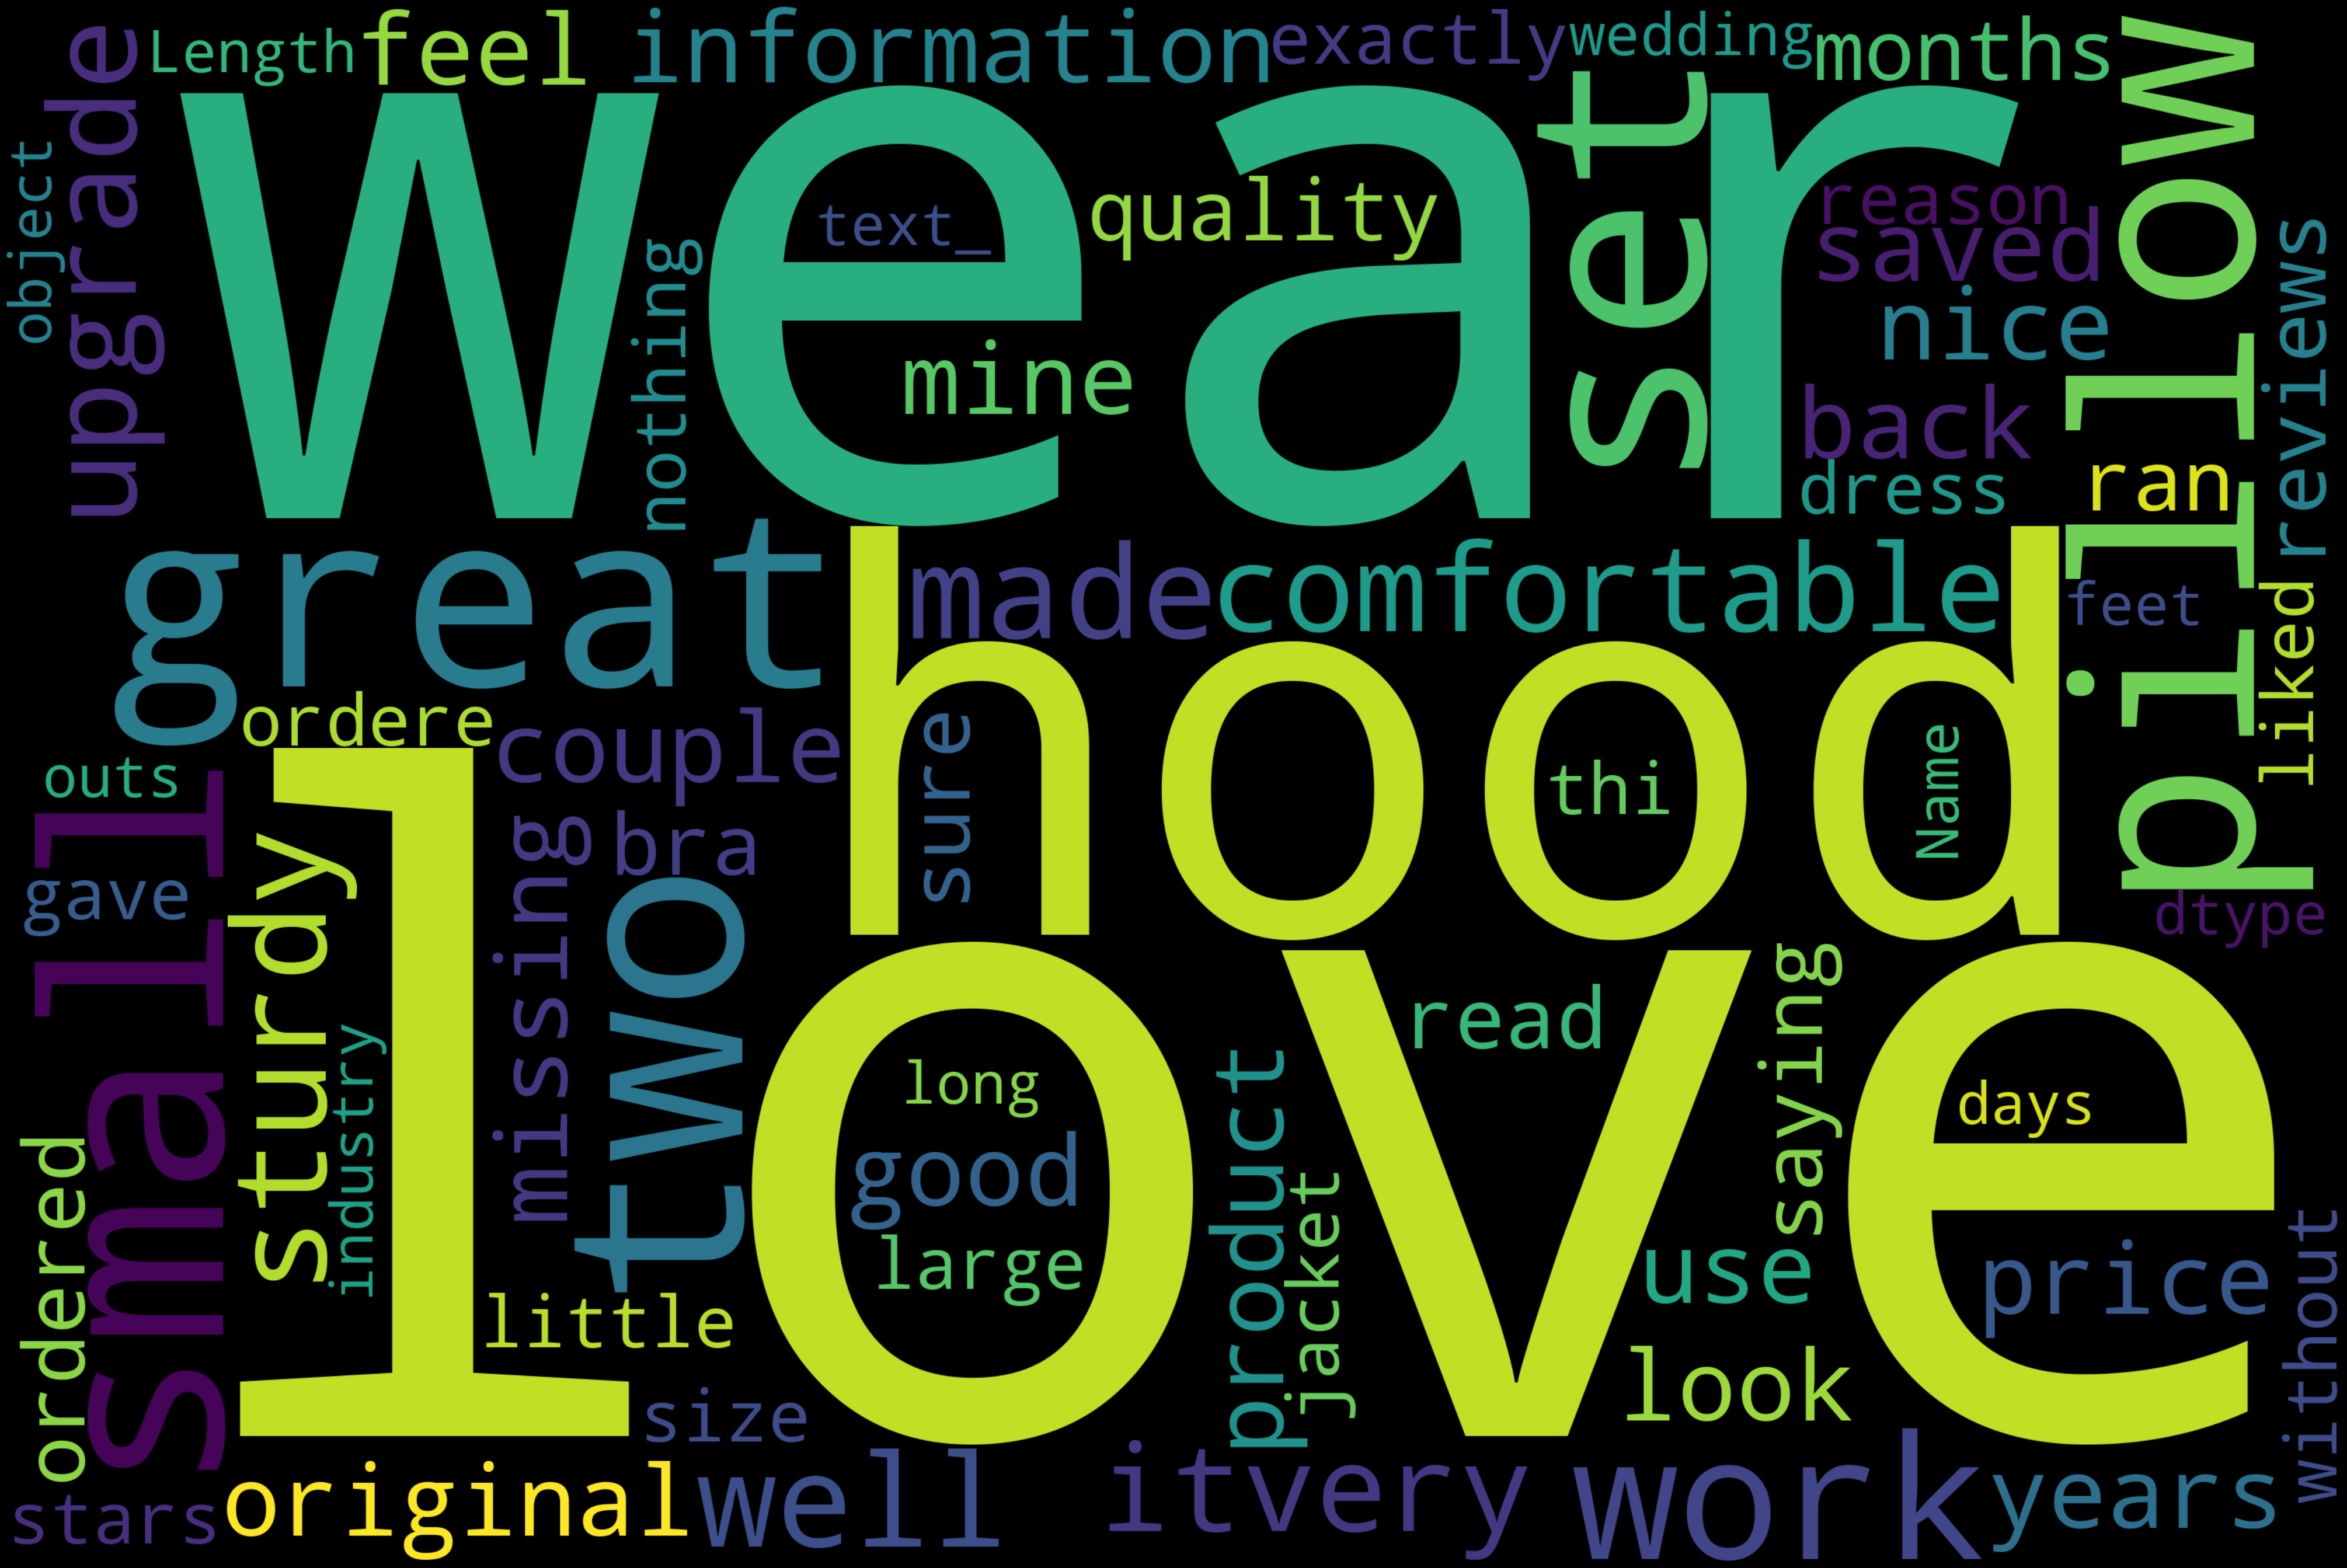

In [29]:
text = cleaned_data["text_"]
wordcloud = WordCloud(
    width = 3000,
    height = 2000,
    background_color = 'black',
    stopwords = STOPWORDS).generate(str(text))
fig = plt.figure(
    figsize = (40, 30),
    facecolor = 'k',
    edgecolor = 'k')
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

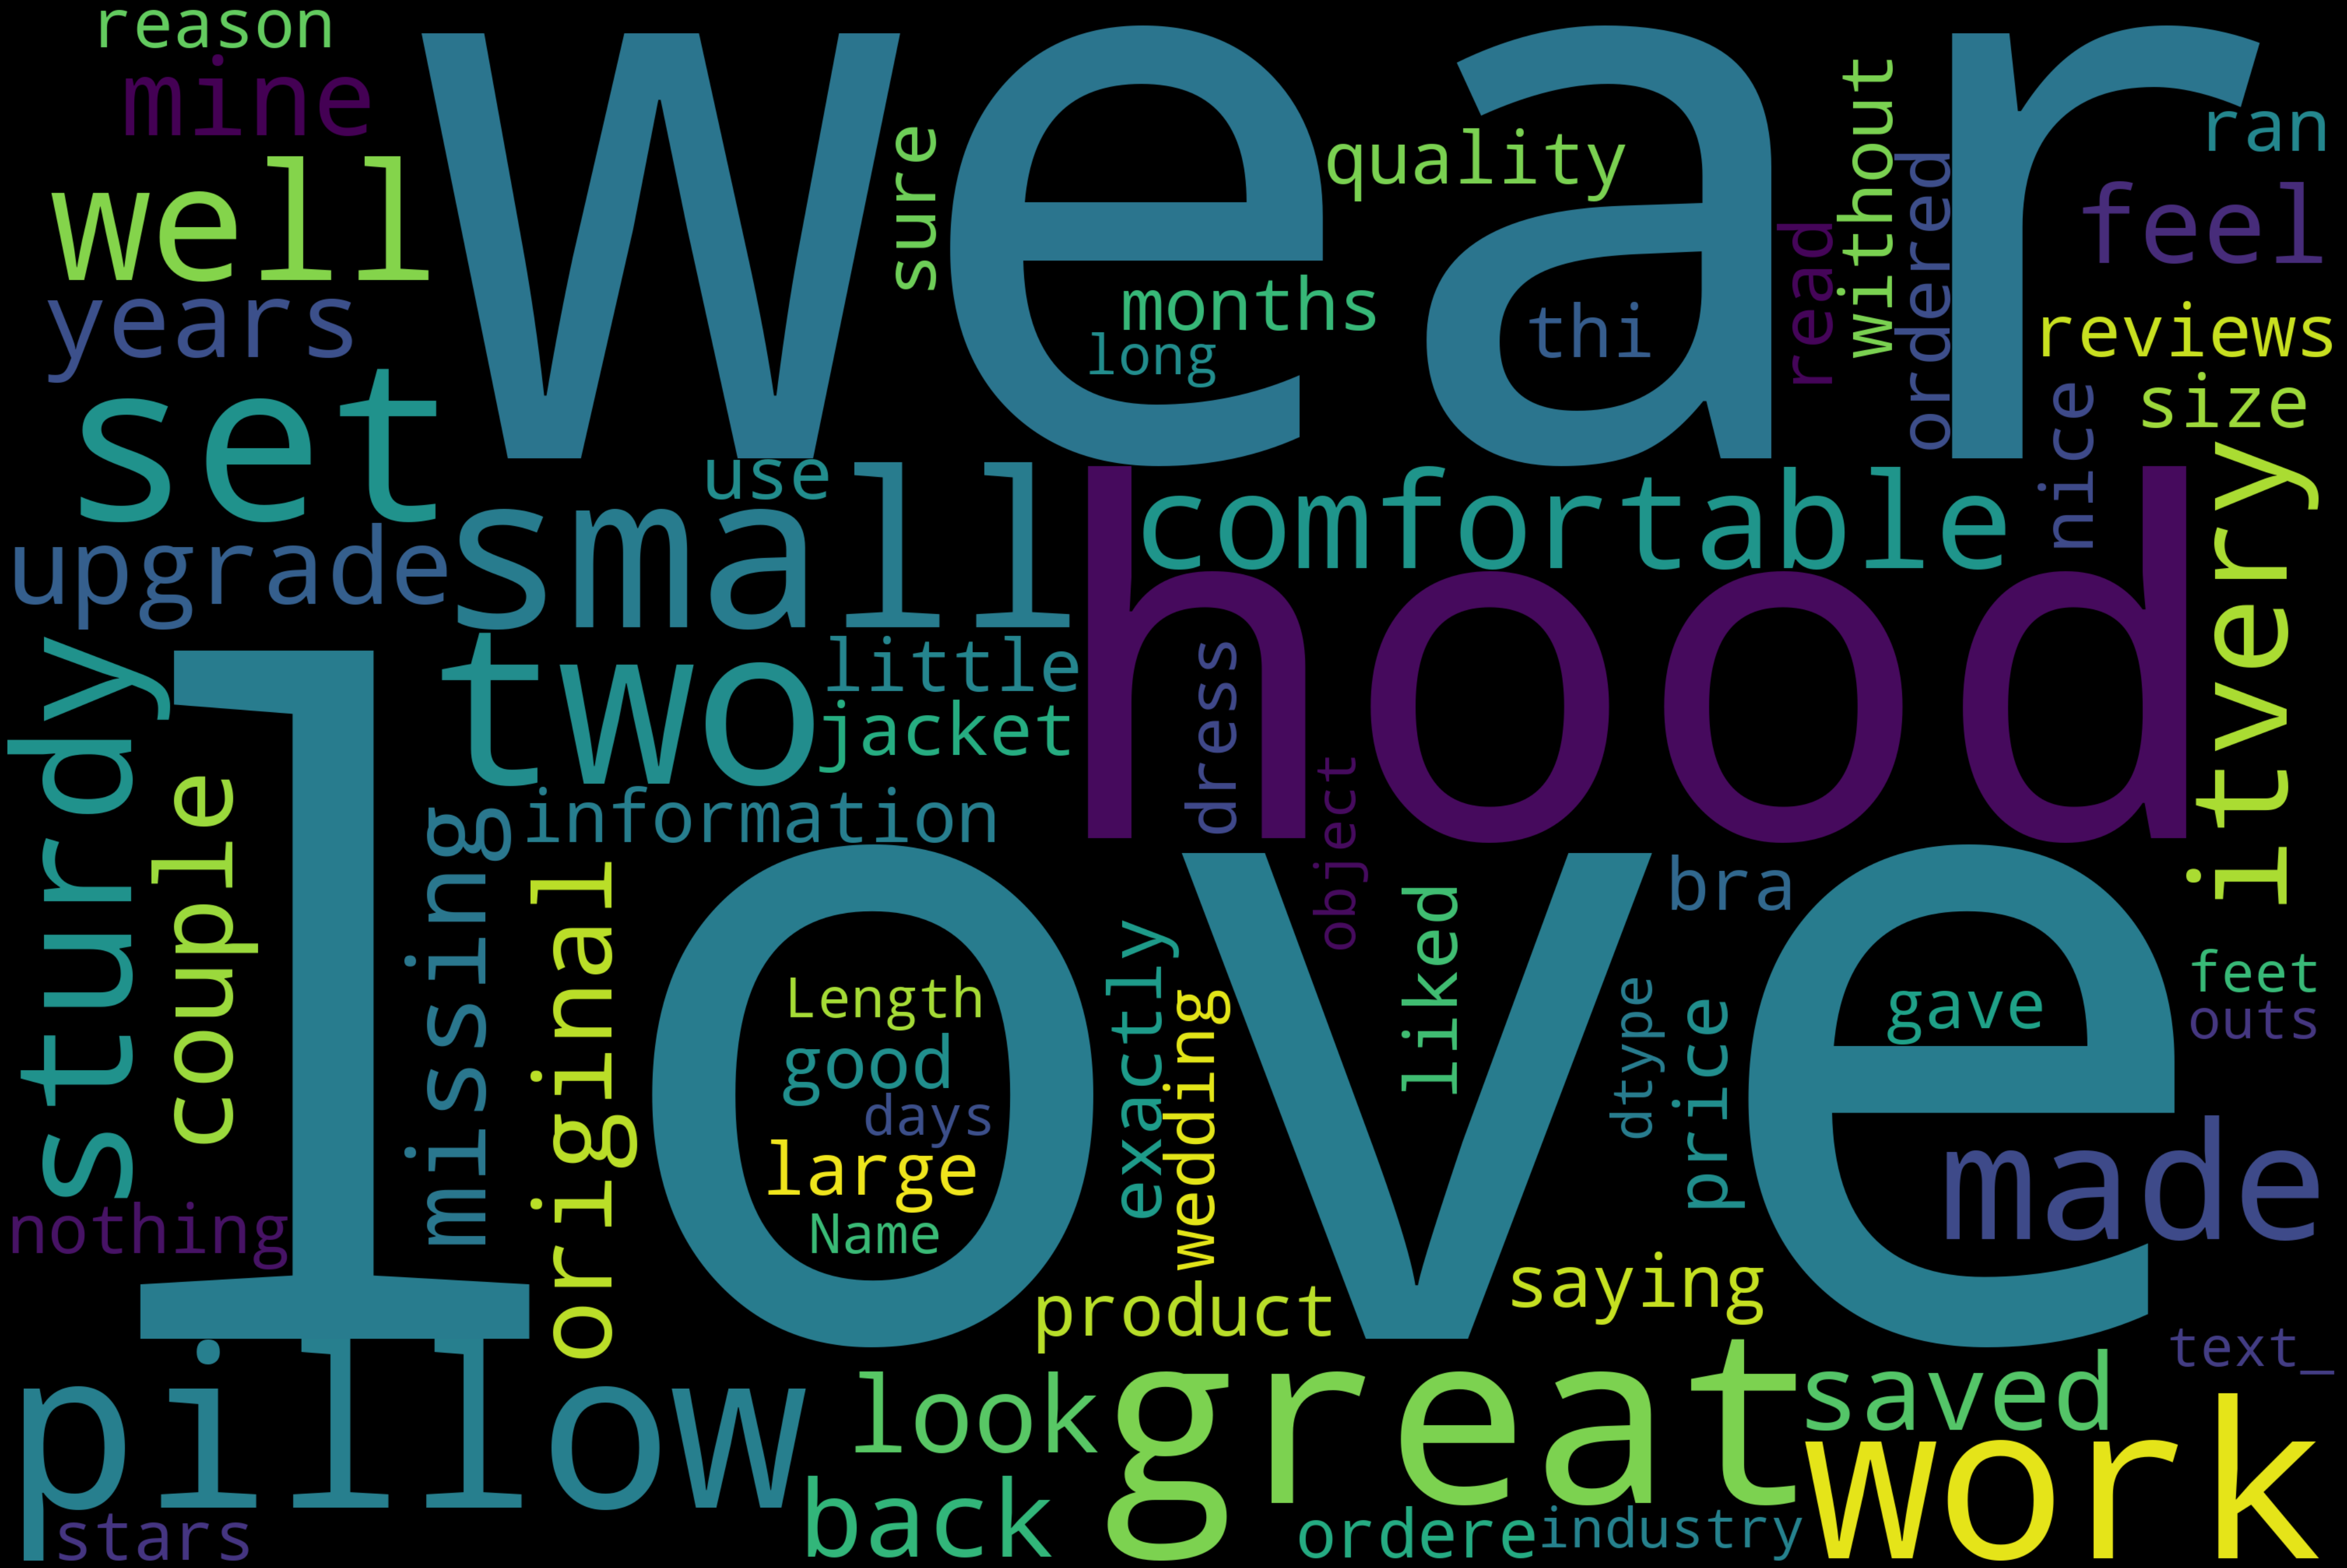

In [30]:
text = cleaned_data["text_"]
wordcloud = WordCloud(
    width = 3000,
    height = 2000,
    background_color = 'black',
    stopwords = STOPWORDS).generate(str(text))
fig = plt.figure(
    figsize = (40, 30),
    facecolor = 'k',
    edgecolor = 'k')
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [14]:
cleaned_data.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,love well made sturdy comfortable love itvery ...
1,Home_and_Kitchen_5,5.0,CG,love great upgrade original mine couple years
2,Home_and_Kitchen_5,5.0,CG,pillow saved back love look feel pillow
3,Home_and_Kitchen_5,1.0,CG,missing information use great product price
4,Home_and_Kitchen_5,5.0,CG,nice set good quality set two months


In [15]:
cleaned_data['class'] = cleaned_data['label'].map({'CG': 0, 'OR': 1})

In [16]:
cleaned_data.head()

,category,rating,label,text_,class
0,Home_and_Kitchen_5,5.0,CG,love well made sturdy comfortable love itvery ...,0
1,Home_and_Kitchen_5,5.0,CG,love great upgrade original mine couple years,0
2,Home_and_Kitchen_5,5.0,CG,pillow saved back love look feel pillow,0
3,Home_and_Kitchen_5,1.0,CG,missing information use great product price,0
4,Home_and_Kitchen_5,5.0,CG,nice set good quality set two months,0


# Train, Test, and Validation

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = cleaned_data['text_']
y = cleaned_data['class']

KeyError: 'class'

In [ ]:
X_train, X_remaining, y_train, y_remaining = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(X_remaining, y_remaining, stratify=y_remaining, test_size=0.5, random_state=42)

## Transformers

In [ ]:
from transformers import DistilBertTokenizer, TFDistilBertModel
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = TFDistilBertModel.from_pretrained("distilbert-base-uncased")

In [ ]:
import tensorflow as tf

In [ ]:
MAX_LENGTH = 128
def batch_encode(tokenizer, texts, batch_size=256, max_length=MAX_LENGTH):
    
    
    input_ids = []
    attention_mask = []
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer.batch_encode_plus(batch,
                                             max_length=max_length,
                                             padding='max_length', 
                                             truncation=True,
                                             return_attention_mask=True,
                                             return_token_type_ids=False
                                             )
        input_ids.extend(inputs['input_ids'])
        attention_mask.extend(inputs['attention_mask'])
    
    
    return tf.convert_to_tensor(input_ids), tf.convert_to_tensor(attention_mask)

In [ ]:
X_train_ids, X_train_attention = batch_encode(tokenizer, X_train.tolist())
X_train_ids

In [ ]:
X_valid_ids, X_valid_attention = batch_encode(tokenizer, X_val.tolist())

# Encode X_test
X_test_ids, X_test_attention = batch_encode(tokenizer, X_test.tolist())

# RoBERTa Model

In [14]:
def build_distilbert_model(max_length):
    # Configure DistilBERT's initialization
    config = DistilBertConfig(dropout=0.2, attention_dropout=0.2, output_hidden_states=False)
    distilbert = TFDistilBertModel.from_pretrained('distilbert-base-uncased', config=config)

    # Define model inputs
    input_ids = tf.keras.layers.Input(shape=(max_length,), dtype=tf.int32, name='input_ids')
    attention_mask = tf.keras.layers.Input(shape=(max_length,), dtype=tf.int32, name='attention_mask')

    # Get the embeddings from DistilBERT
    embeddings = distilbert(input_ids, attention_mask=attention_mask)[0]

    # Example downstream layers
    x = tf.keras.layers.GlobalAveragePooling1D()(embeddings)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    # Compile the model
    model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5), loss='binary_crossentropy', metrics=['accuracy'])

    return model



In [15]:
import matplotlib.pyplot as plt
from keras.models import Sequential, Model
from keras.layers import Dense, LSTM, Embedding, Dropout, GRU, Input, Conv1D, MaxPool1D, GlobalMaxPooling1D, Flatten, concatenate, SpatialDropout1D, GlobalAveragePooling1D
from keras.constraints import MaxNorm

In [16]:
from sklearn.metrics import classification_report,accuracy_score,f1_score, precision_recall_fscore_support

In [17]:
import math
import tensorflow as tf
import keras

# MODEL

In [23]:
MAX_LENGTH = 128
LAYER_DROPOUT = 0.2
LEARNING_RATE = 1e-4
RANDOM_STATE = 42

def custom_drc(transformer, max_length=MAX_LENGTH):
    
    
    weight_initializer = tf.keras.initializers.GlorotNormal(seed=RANDOM_STATE) 
    
    
    input_ids_layer1 = tf.keras.layers.Input(shape=(max_length,), 
                                            name='input_ids', 
                                            dtype='int32')
    input_attention_layer1 = tf.keras.layers.Input(shape=(max_length,), 
                                                  name='input_attention', 
                                                  dtype='int32')
    
    
    last_hidden_state1 = transformer([input_ids_layer1, input_attention_layer1])[1]
    
    #model1
    dense1_1 = Dense(128, activation="relu")(last_hidden_state1)
    drop1_1 = Dropout(0.2)(dense1_1)
    dense1_2 = Dense(128, activation="relu")(drop1_1)
    flat1 = Flatten()(dense1_2)
    drop1_2 = Dropout(0.2)(flat1)
    out1 = output = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop1_2)
    
    
    
    #model2
    gru_layer5_1 = GRU(128, activation='tanh', return_sequences=True)(last_hidden_state1) 
    drop5_1 = Dropout(0.5)(gru_layer5_1)
    lstm_layer5 = LSTM(64, activation='tanh', return_sequences=True)(drop5_1)
    drop5_2 = Dropout(0.5)(lstm_layer5)
    gru_layer5_2 = GRU(32, activation='tanh')(drop5_2)
    drop5_3 = Dropout(0.5)(gru_layer5_2)
    out2 = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop5_3)
    
    #model3
    max_length = None
                 
    conv1 = Conv1D(filters=128, kernel_size=4, activation='relu', 
               kernel_constraint= MaxNorm( max_value=3, axis=[0,1]))(last_hidden_state1)
    pool1 = MaxPool1D(pool_size=2, strides=2)(conv1)
    flat3 = Flatten()(pool1)
    drop6 = Dropout(0.4)(flat3)
    dense3 = Dense(32, activation='relu')(drop6)
    drop7 = Dropout(0.4)(dense3)
    out3 = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop7)
    
    merge = concatenate([out1, out2, out3])
    
    outputs = Dense(2, activation='softmax')(merge)
    
    model = Model(inputs=[input_ids_layer1, input_attention_layer1], outputs=outputs)
    
    model.compile( loss='sparse_categorical_crossentropy', optimizer= tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),  metrics=['accuracy'])
    model.summary()
    return model

In [24]:
drc_model = custom_drc(build_model, max_length=128)

TypeError: build_model() takes 0 positional arguments but 1 was given

In [ ]:
EPOCHS =10 
BATCH_SIZE = 50
NUM_STEPS = len(X_train.index) // BATCH_SIZE

# Train the model
train_history4 = drc_model.fit(
    x = [X_train_ids, X_train_attention],
    y = y_train.to_numpy(),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    steps_per_epoch = NUM_STEPS,
    validation_data = ([X_valid_ids, X_valid_attention], y_val.to_numpy()),
    
)

Epoch 1/10


566/566 [==============================] - 1648s 3s/step - loss: 0.5487 - accuracy: 0.7366 - val_loss: 0.4814 - val_accuracy: 0.7707
Epoch 2/10
566/566 [==============================] - 1732s 3s/step - loss: 0.4698 - accuracy: 0.7976 - val_loss: 0.4535 - val_accuracy: 0.8130
Epoch 3/10
566/566 [==============================] - 1500s 3s/step - loss: 0.4386 - accuracy: 0.8162 - val_loss: 0.4054 - val_accuracy: 0.8399
Epoch 4/10
566/566 [==============================] - 1323s 2s/step - loss: 0.4240 - accuracy: 0.8312 - val_loss: 0.3971 - val_accuracy: 0.8384
Epoch 5/10
566/566 [==============================] - 1321s 2s/step - loss: 0.3930 - accuracy: 0.8417 - val_loss: 0.3655 - val_accuracy: 0.8577
Epoch 6/10
566/566 [==============================] - 1318s 2s/step - loss: 0.3701 - accuracy: 0.8552 - val_loss: 0.3695 - val_accuracy: 0.8519
Epoch 7/10
144/566 [======>.......................] - ETA: 13:38 - loss: 0.3541 - accuracy: 0.8648

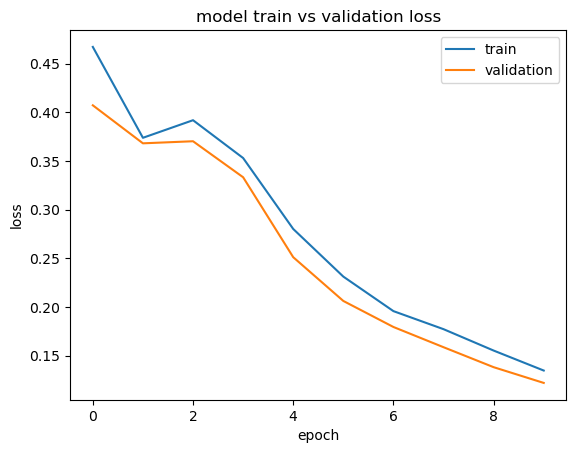

In [76]:
plt.plot(train_history4.history['loss'])
plt.plot(train_history4.history['val_loss'])
plt.title('model train vs validation loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show() 

In [77]:
y_predict = drc_model.predict([X_test_ids, X_test_attention]).argmax(axis=-1)
y_pr = [int(x+0.5) for x in y_predict]

211/211 [==============================] - 209s 977ms/step


In [79]:
F1 = precision_recall_fscore_support(y_test, y_pr, average='micro')
F1

(0.9989601901366607, 0.9989601901366607, 0.9989601901366607, None)

In [80]:
classification_report(y_test, y_pr)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00      3521\n           1       1.00      1.00      1.00      3211\n\n    accuracy                           1.00      6732\n   macro avg       1.00      1.00      1.00      6732\nweighted avg       1.00      1.00      1.00      6732\n'